In [ ]:
!pip install rdkit
!pip install xgboost



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 31.7 MB/s eta 0:00:00


Import requried Libraries

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report



Load Dataset

In [ ]:
df = pd.read_csv("/content/train.csv")
smiles_list = df["SMILES"].values
labels = df["Label"].values # 0 = Safe, 1 = Hazardous


print("Safe (0):", sum(labels == 0))
print("Hazardous (1):", sum(labels == 1))


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x90 in position 10: invalid start byte

Convert smiles to Morgan fingerprints


In [ ]:
def smiles_to_morgan(smiles, radius=3, nBits=4096):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=int)
    AllChem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


Turns off warning-level logs

In [ ]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')


It stacks all molecule fingerprints into a 2D NumPy array where each row represents one molecule.

In [ ]:
X = np.vstack([smiles_to_morgan(s) for s in smiles_list])


[13:17:53] Explicit valence for atom # 2 Cl, 1, is greater than permitted
[13:17:54] Explicit valence for atom # 0 Cl, 1, is greater than permitted


It splits your dataset into training and validation

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)


It scales features to have mean 0 and standard deviation 1 so all features contribute equally to model training.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


Moving your data to device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)


Importing xgboost for making predictions


Give more weight to the minority class so the model doesn’t ignore it.

In [ ]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)


scale_pos_weight: 7.209333333333333


Defining MLP Model

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, h1=256, h2=64, d1=0.3, d2=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.BatchNorm1d(h1),
            nn.Dropout(d1),

            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(d2),

            nn.Linear(h2, 1)
        )

    def forward(self, x):
        return self.net(x)


Create an instance of your MLP model with the correct input size

In [ ]:
model = MLP(X_train.shape[1])

Hyperparameters

In [ ]:
param_grid = {
    "h1": [128, 256],
    "h2": [32, 64],
    "d1": [0.2, 0.3],
    "d2": [0.1, 0.2],
    "lr": [0.001, 0.0005]
}


Training and Evaluating MLP with hyperparameters

In [ ]:
from sklearn.metrics import f1_score
import torch.optim as optim
import torch.nn as nn

def train_and_eval(params):
    model = MLP(
        input_dim=X_train.shape[1],
        h1=params["h1"],
        h2=params["h2"],
        d1=params["d1"],
        d2=params["d2"]
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=params["lr"])

    for epoch in range(30):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train).squeeze()
        loss = criterion(outputs, y_train.float())
        loss.backward()
        optimizer.step()

    # ---- Evaluation ----
    model.eval()
    with torch.no_grad():
        logits = model(X_val).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.4).int()   # threshold tuning

    f1 = f1_score(y_val.cpu(), preds.cpu())
    return f1


In [ ]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report


Tuning XGBoost classifier

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # KEY LINE
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)


Training the XGBoost model

In [ ]:
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

Computes the predicted probabilities for the positive class

In [ ]:
probs = xgb_model.predict_proba(X_val)[:, 1]

Evaluate model performance at different probability thresholds

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    preds = (probs > t).astype(int)
    p = precision_score(y_val, preds)
    r = recall_score(y_val, preds)
    f = f1_score(y_val, preds)
    print(f"Threshold={t:.2f} | Precision={p:.2f} | Recall={r:.2f} | F1={f:.2f}")


Threshold=0.30 | Precision=0.23 | Recall=0.61 | F1=0.34
Threshold=0.35 | Precision=0.27 | Recall=0.58 | F1=0.37
Threshold=0.40 | Precision=0.32 | Recall=0.57 | F1=0.41
Threshold=0.45 | Precision=0.36 | Recall=0.52 | F1=0.43
Threshold=0.50 | Precision=0.39 | Recall=0.50 | F1=0.44


Focal Loss is used to handle class imbalance.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return loss.mean()




seting the loss function for training your model

In [ ]:
criterion = FocalLoss(alpha=0.85, gamma=2)


Optimizer(tells the model how to adjust its weights to improve.)

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0002,
    weight_decay=1e-5
)


Training a  pytorch model

In [ ]:
num_epochs = 100
learning_rate = 0.0002
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t)
        val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {loss.item():.4f} | "
          f"Val Loss: {val_loss.item():.4f}")


Epoch 1/100 | Train Loss: 0.2363 | Val Loss: 0.1888
Epoch 2/100 | Train Loss: 0.2227 | Val Loss: 0.1852
Epoch 3/100 | Train Loss: 0.2066 | Val Loss: 0.1817
Epoch 4/100 | Train Loss: 0.1939 | Val Loss: 0.1784
Epoch 5/100 | Train Loss: 0.1817 | Val Loss: 0.1751
Epoch 6/100 | Train Loss: 0.1717 | Val Loss: 0.1717
Epoch 7/100 | Train Loss: 0.1614 | Val Loss: 0.1681
Epoch 8/100 | Train Loss: 0.1525 | Val Loss: 0.1644
Epoch 9/100 | Train Loss: 0.1442 | Val Loss: 0.1606
Epoch 10/100 | Train Loss: 0.1361 | Val Loss: 0.1565
Epoch 11/100 | Train Loss: 0.1292 | Val Loss: 0.1524
Epoch 12/100 | Train Loss: 0.1229 | Val Loss: 0.1481
Epoch 13/100 | Train Loss: 0.1168 | Val Loss: 0.1438
Epoch 14/100 | Train Loss: 0.1113 | Val Loss: 0.1394
Epoch 15/100 | Train Loss: 0.1065 | Val Loss: 0.1350
Epoch 16/100 | Train Loss: 0.1011 | Val Loss: 0.1307
Epoch 17/100 | Train Loss: 0.0963 | Val Loss: 0.1265
Epoch 18/100 | Train Loss: 0.0924 | Val Loss: 0.1224
Epoch 19/100 | Train Loss: 0.0884 | Val Loss: 0.1185
Ep

Converts predicted probabilities to binary predictions

In [ ]:

threshold = 0.4
preds = (probs > threshold).astype(int)

print(confusion_matrix(y_val, preds))
print(classification_report(y_val, preds))


[[1129  224]
 [  81  106]]
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      1353
           1       0.32      0.57      0.41       187

    accuracy                           0.80      1540
   macro avg       0.63      0.70      0.65      1540
weighted avg       0.86      0.80      0.82      1540



 Plots a heatmap of the confusion matrix

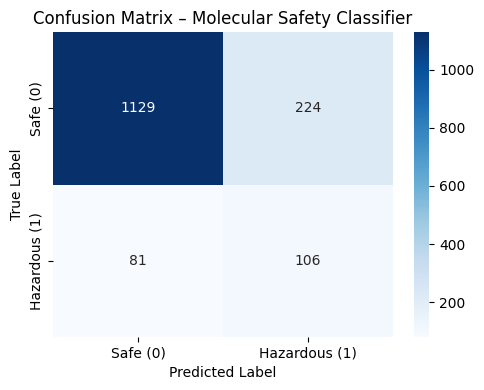

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix values
cm = np.array([
    [1129, 224],
    [81, 106]
])

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Safe (0)", "Hazardous (1)"],
    yticklabels=["Safe (0)", "Hazardous (1)"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Molecular Safety Classifier")
plt.tight_layout()
plt.show()



Plots a bar chart of precision, recall, and F1-score for each class

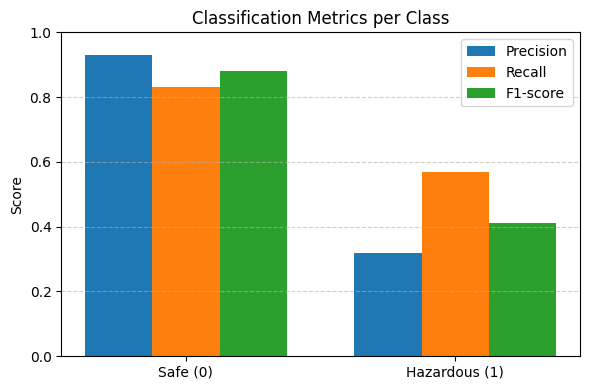

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for each class
classes = ["Safe (0)", "Hazardous (1)"]

precision = [0.93, 0.32]
recall    = [0.83, 0.57]
f1_score  = [0.88, 0.41]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(6,4))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1_score, width, label="F1-score")

plt.xticks(x, classes)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Classification Metrics per Class")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


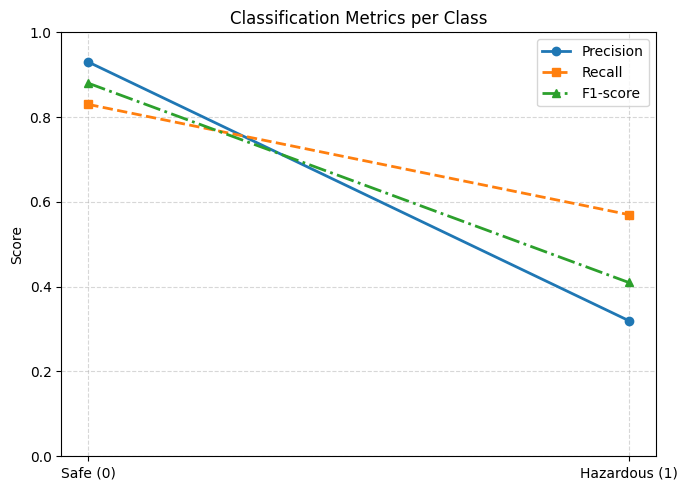

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
classes = ["Safe (0)", "Hazardous (1)"]

# Metrics for each class
precision = [0.93, 0.32]
recall    = [0.83, 0.57]
f1_score  = [0.88, 0.41]

# X-axis positions
x = np.arange(len(classes))

plt.figure(figsize=(7,5))

# Plot smooth curves with markers
plt.plot(x, precision, marker='o', linestyle='-', linewidth=2, label='Precision', color='tab:blue')
plt.plot(x, recall, marker='s', linestyle='--', linewidth=2, label='Recall', color='tab:orange')
plt.plot(x, f1_score, marker='^', linestyle='-.', linewidth=2, label='F1-score', color='tab:green')

# Labels and titles
plt.xticks(x, classes)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Classification Metrics per Class")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
